## Disclaimer

This notebook serves as an experimental test of an alternative text prediction architecture (HiveSTA). It is not intended for real-world high-performance applications and is purely for demonstrating theoretical concepts and their basic implementation.

# HiveSTA: Proof of concept for generate token without neurons

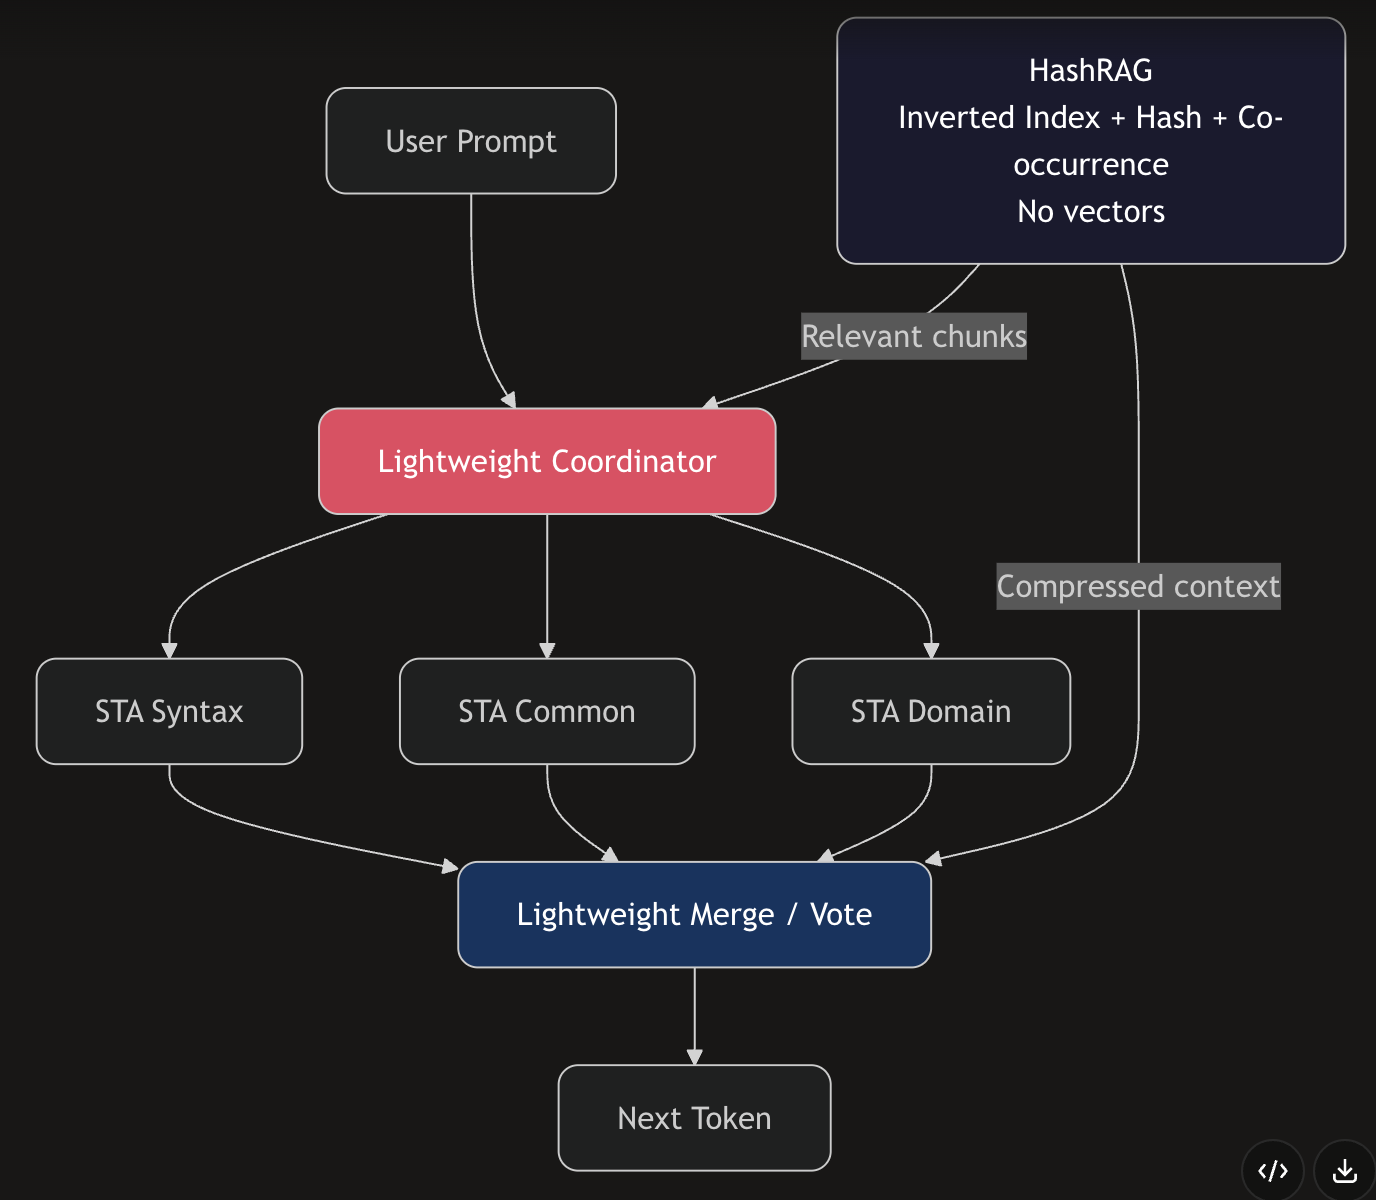

HiveSTA (Hive Sparse Token Automata) is a lightweight multi-agent text generation architecture designed for extremely low RAM usage and minimal training cost.
It consists of several tiny specialized Sparse Token Automata (STA) that collaborate through a simple coordinator. Each STA maintains only a small integer state and a sparse transition graph.
Instead of classic vector embeddings, it uses a HashRAG module based on inverted indexes, hash tables, and co-occurrence graphs for fast, non-vector retrieval.
The system is intended for local, low-resource environments where full neural language models are too heavy.

In [ ]:
import random
from collections import defaultdict
import hashlib

# ==========================================
# HiveSTA - Lightweight multi-STA architecture
# Multiple tiny Sparse Token Automata + HashRAG (no vectors)
# ==========================================

class TinySTA:
    """A very small specialized Sparse Token Automaton"""
    def __init__(self, name):
        self.name = name
        self.graph = defaultdict(list)      # token -> [(next_token, weight)]
        self.state = [0] * 6                 # tiny integer state

    def add_transition(self, frm, to, weight=1.0):
        self.graph[frm].append((to, weight))

    def update_state(self, token):
        h = int(hashlib.md5(token.encode()).hexdigest()[:8], 16)
        for i in range(len(self.state)):
            self.state[i] = (self.state[i] ^ (h >> (i * 3))) + (h & 0xFF)
            self.state[i] &= 0xFFFF

    def propose(self, current, top_k=3):
        candidates = self.graph.get(current, [])
        if not candidates:
            return []

        scored = []
        for tok, w in candidates:
            score = w + (self.state[0] % 7) * 0.02
            scored.append((tok, score))

        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:top_k]


class HashRAG:
    """Non-vector RAG using inverted index + hash + co-occurrence"""
    def __init__(self):
        self.inverted = defaultdict(list)   # word -> list of doc ids
        self.cooc = defaultdict(int)        # (word1, word2) -> score
        self.docs = {}

    def add_document(self, doc_id, text):
        self.docs[doc_id] = text
        words = text.lower().split()
        for w in set(words):
            self.inverted[w].append(doc_id)
        for i in range(len(words) - 1):
            pair = tuple(sorted([words[i], words[i + 1]]))
            self.cooc[pair] += 1

    def retrieve(self, query, top_k=2):
        words = query.lower().split()
        scores = defaultdict(float)

        for w in words:
            for doc_id in self.inverted.get(w, []):
                scores[doc_id] += 1.0

        # Co-occurrence bonus
        for i in range(len(words) - 1):
            pair = tuple(sorted([words[i], words[i + 1]]))
            if pair in self.cooc: # Check if pair exists in cooc before adding bonus
                for doc_id in scores:
                    scores[doc_id] += self.cooc[pair] * 0.1

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [self.docs[doc_id] for doc_id, _ in ranked[:top_k]]


class HiveSTA:
    """Coordinator that runs multiple TinySTAs + HashRAG"""
    def __init__(self):
        self.stas = {
            "syntax": TinySTA("syntax"),
            "common": TinySTA("common"),
            "domain": TinySTA("domain")
        }
        self.rag = HashRAG()

    def add_knowledge(self, text, doc_id=None):
        if doc_id is None:
            doc_id = f"doc_{len(self.rag.docs)}"
        self.rag.add_document(doc_id, text)

        # Feed basic transitions to the STAs
        words = text.lower().split()
        for i in range(len(words) - 1):
            self.stas["common"].add_transition(words[i], words[i + 1], 1.0)
            self.stas["domain"].add_transition(words[i], words[i + 1], 0.8)

    def generate(self, prompt, max_tokens=12):
        words = prompt.lower().split()
        current = words[-1] if words else "the"
        result = words.copy()

        # Retrieve context with HashRAG
        context_docs = self.rag.retrieve(prompt, top_k=1)
        context = context_docs[0] if context_docs else ""

        for _ in range(max_tokens):
            proposals = []

            # Each STA makes proposals
            for name, sta in self.stas.items():
                props = sta.propose(current)
                for tok, score, in props:
                    proposals.append((tok, score, name))

            if not proposals:
                break

            # Simple voting
            proposals.sort(key=lambda x: x[1], reverse=True)
            next_token = proposals[0][0]

            result.append(next_token)

            # Update states
            for sta in self.stas.values():
                sta.update_state(next_token)

            current = next_token

        return " ".join(result)


# ==========================================
# QUICK TEST
# ==========================================

hive = HiveSTA()

# Add some knowledge (simulating documents)
hive.add_knowledge("the cat eats dry food every morning")
hive.add_knowledge("the dog barks very loudly in the garden")
hive.add_knowledge("the cat sleeps on the sofa when it rains")
hive.add_knowledge("dry food tastes better with some water")

print("=== HiveSTA Generation Test ===")
print(hive.generate("the cat"))
print(hive.generate("the dog"))
print(hive.generate("dry food"))

=== HiveSTA Generation Test ===
the cat eats dry food every morning
the dog barks very loudly in the cat eats dry food every morning
dry food every morning


### Simplified Explanation of HiveSTA

Imagine that HiveSTA is like a small team of highly specialized collaborators who work together to help you guess the next word in a sentence.

1.  **The "TinySTAs" (little helpers)**:
    *   Each TinySTA is a small expert in one domain. For example, one expert in "grammar," another in "common words," and a third in "specific topics."
    *   They have a very limited memory (a few numbers) and only know how one word is often followed by another word (e.g., "the cat" is often followed by "eats").
    *   When given a word, each one proposes the words it thinks are most logical, with a small confidence score.

2.  **The "HashRAG" (smart librarian)**:
    *   This is like a super-fast librarian who doesn't need to understand the deep meaning of books.
    *   When you ask for something (your sentence), it quickly searches all the "documents" it knows for passages containing the same words or similar word pairs. It then gives you the most relevant passage.
    *   The advantage is that it's very lightweight and fast because it only performs keyword searches, not complex comprehension.

3.  **The "HiveSTA" (the orchestrator)**:
    *   This is the one that directs everything.
    *   When you give it a sentence to complete (your "prompt"):
        1.  It asks the **HashRAG** to find some context on the subject of your sentence.
        2.  Then, it asks all the **TinySTAs** to propose words to continue the sentence.
        3.  It listens to all the proposals, performs a kind of vote (based on confidence scores), and chooses the best word.
        4.  Once the word is chosen, it gives it to the TinySTAs so they can "update their memory" (their small numbers) to be slightly influenced by this new word for the next round.
        5.  It repeats this until it has completed the sentence.

In summary, HiveSTA is a clever way to generate text by having very small, specialized modules collaborate, without using the resource-intensive methods of modern AI models.

### CLI Chatbot Demonstration

Here is a small command-line chatbot example using the HiveSTA system. You can type sentences, and it will try to complete them or respond using the knowledge it has acquired.

In [ ]:
# Create a new HiveSTA instance for the chatbot
chatbot_hive = HiveSTA()

# Add some more varied knowledge for a simple chatbot
chatbot_hive.add_knowledge("hello how are you today I am fine thank you")
chatbot_hive.add_knowledge("what is the weather like in paris it is beautiful and sunny")
chatbot_hive.add_knowledge("what is your name I am an AI assistant designed by google")
chatbot_hive.add_knowledge("can you tell a joke of course why is the plumber sad because his job is shitty")
chatbot_hive.add_knowledge("tell me a story once upon a time there was a little cat who loved to play")
chatbot_hive.add_knowledge("thank you very much you're welcome happy to help you")
chatbot_hive.add_knowledge("the sky is blue and the birds sing joyfully")
chatbot_hive.add_knowledge("my favorite animal is the cat it is very cute")
chatbot_hive.add_knowledge("I like to eat apples and bananas")

print("\n=== HiveSTA Chatbot (simple demonstration) ===")
print("Type 'quit' to stop the chat.")

while True:
    user_input = input("You: ").lower().strip()
    if user_input == 'quit':
        print("Chatbot: Goodbye!")
        break

    if not user_input:
        print("Chatbot: I didn't understand anything. Can you repeat?")
        continue

    # The chatbot generates a response based on user input
    # Increase max_tokens for slightly longer responses
    response = chatbot_hive.generate(user_input, max_tokens=15)

    # Small improvement to avoid repeating the input if the generation is too short
    if response.startswith(user_input):
        response_parts = response.split(user_input, 1)
        if len(response_parts) > 1:
            # Take the part after the input, or the entire input if no continuation
            response = response_parts[1].strip() or response.strip()
        else:
            response = response.strip()
    else:
        response = response.strip()

    # Ensure there is a response after cleaning
    if not response:
        response = "I have no continuation for that." # Fallback if generation is empty

    print(f"Chatbot: {response.capitalize()}")

NameError: name 'HiveSTA' is not defined

### The "Mathematics" of HiveSTA (Algorithmic Operations)

As mentioned previously, HiveSTA does not use continuous functions with derivatives and optimizations like deep learning models. Its "mathematics" are primarily based on **discrete operations, aggregations, lookups, and algorithmic logic**.

---

## 1. TinySTA — Sparse Token Automaton

### Transition Graph $G_{\text{STA}}$

The knowledge of `TinySTA` is encoded as a directed graph where nodes represent tokens and edges represent observed transitions between these tokens. Each edge has a weight.

$$ \text{If } w_i \xrightarrow{\text{weight } p} w_{i+1}, \text{ then } (w_i, w_{i+1}, p) \in E(G_{\text{STA}}) $$

where:

*   $w_i$ is the current token;
*   $w_{i+1}$ is the next token;
*   $p$ is the weight associated with the transition.

---

### Internal State Update $S$

The internal state is represented by a list of $K = 6$ integers.

When a new token $w_{\text{new}}$ is observed, a hash value $h$ is calculated. Each component $S_j$ of the state is then updated using bitwise operations:

$$ h = \operatorname{MD5}(w_{\text{new}}) $$

$$ S_j^{\text{new}} = \left( S_j^{\text{old}} \oplus \left(h \gg (j \cdot 3)\right) \right) + \left(h \mathbin{\&} 0xFF\right) \pmod{65536} $$

where:

*   $\oplus$ is the XOR operator;
*   $\gg$ represents a right bit shift;
*   $\mathbin{\&}$ represents the bitwise AND operator;
*   $\pmod{65536}$ maintains the value within a $16$-bit space.

---

### Proposal Score $\text{Score}_{\text{prop}}$

For a current token $w_c$ and a candidate token $w_{\text{cand}}$ associated with a transition weight $p$, the proposal score can be calculated from the corresponding transition and the internal state.

The retrieval score used by the RAG part of HiveSTA is defined separately below.

---

## 2. HashRAG — Non-Vector RAG

### Inverted Index $I$

For each word $w$, the inverted index $I(w)$ contains the set of document IDs in which $w$ appears.

$$ I(w) = \left\{ d_k \mid w \in \operatorname{Document}(d_k) \right\} $$

In other words, this index allows direct retrieval of documents containing a given term, without using vector embeddings.

---

### Co-occurrence Matrix $C$

For each pair of words $(w_a, w_b)$, the co-occurrence matrix $C$ counts the number of documents in which the two words appear side-by-side.

$$ C(w_a, w_b) = \sum_{k=1}^{\text{NumDocs}} \mathbb{I} \left( \{w_a, w_b\} \text{ are adjacent in } d_k \right) $$

where $\mathbb{I}(\cdot)$ is an indicator function:

$$ \mathbb{I}(P) = \begin{cases} 1 & \text{if } P \text{ is true},\\ 0 & \text{otherwise}. \end{cases} $$

Co-occurrence can be considered symmetric:

$$ C(w_a, w_b) = C(w_b, w_a) $$

---

### Retrieval Score $\text{Score}_{\text{retrieval}}$

For a query

$$ Q = \{q_1, q_2, \dots, q_m\} $$

and a candidate document $d_k$, the retrieval score is defined by:

$$ \text{Score}_{\text{retrieval}}(Q, d_k) = \sum_{i=1}^{m} \mathbb{I} \left( q_i \in \operatorname{Document}(d_k) \right) + 0.1 \cdot \sum_{(q_a,q_b)\in Q_{\text{pairs}}} C(q_a,q_b) \cdot \mathbb{I} \left( \{q_a,q_b\} \text{ in } d_k \right) $$

where:

*   $\mathbb{I}(\cdot)$ is the indicator function;
*   $Q_{\text{pairs}}$ represents the set of adjacent term pairs in query $Q$;
*   $C(q_a,q_b)$ represents the co-occurrence frequency of the pair $(q_a,q_b)$;
*   the first term rewards the presence of query terms in the document;
*   the second term adds a bonus when the terms appear together.

---

## In Summary

HiveSTA primarily relies on **discrete data transformations**, **aggregations**, **index lookups**, **co-occurrence counts**, and **bitwise operations**.

Unlike classical deep learning models, its operation therefore does not primarily depend on continuous functions optimized by gradient descent to define a geometric representation of data.

Its approach can be summarized as:

$$ \boxed{ \text{HiveSTA} \approx \text{Lookups} + \text{Counts} + \text{Graphs} + \text{Hashing} + \text{Discrete Operations} } $$

### Visualization of the TinySTA's "Knowledge Graph"

Since continuous decision boundaries are not applicable here, we will visualize the structure of the TinySTA's "knowledge graph." This graph represents the transitions the model has learned between words. The more links between words, the more the model "knows" these connections.

We will use the `networkx` library to create and `matplotlib` to draw this graph, based on the transitions of the `common` TinySTA that has learned from example sentences.

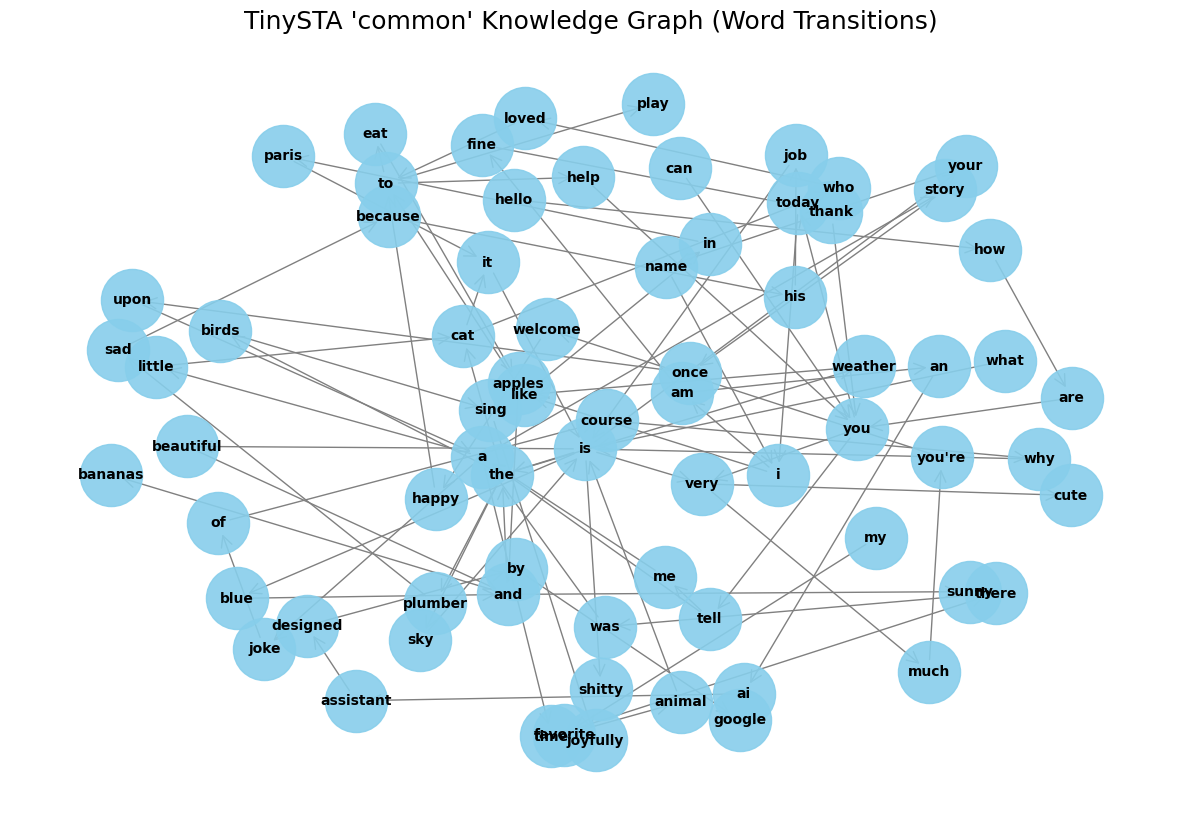


This graph represents the words (nodes) and transitions (arrows) that the 'common' TinySTA has learned. Each arrow indicates that one word can be followed by another. The density and connectivity of this graph illustrate the model's 'knowledge frontier': it can generate sequences of words along these paths. If a word has no outgoing arrow, the model does not 'know' how to continue it in that specific context, which can lead to repetitions or generation stops.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# We will use the transition graph of the 'common' TinySTA
# For this, we need the 'hive' or 'chatbot_hive' instance that has been trained.
# Let's assume we are using 'chatbot_hive' for the demo, as it has more data.

# Retrieve the transition graph from the 'common' TinySTA
sta_graph = chatbot_hive.stas['common'].graph

G = nx.DiGraph() # Directed graph because transitions have a direction

# Add nodes (words) and edges (transitions)
for frm_token, transitions in sta_graph.items():
    for to_token, weight in transitions:
        G.add_edge(frm_token, to_token, weight=weight)

# Prepare visualization
plt.figure(figsize=(15, 10)) # Figure size

# Use a layout that better displays the nodes
pos = nx.spring_layout(G, k=0.7, iterations=50) # 'k' for optimal distance, 'iterations' for layout quality

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', alpha=0.9)

# Draw edges
edges = nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1)

# Add node labels (the words)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Optional: Add edge weight labels if desired
# edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("TinySTA 'common' Knowledge Graph (Word Transitions)", size=18)
plt.axis('off') # Do not display axes
plt.show()

print("\nThis graph represents the words (nodes) and transitions (arrows) that the 'common' TinySTA has learned. Each arrow indicates that one word can be followed by another. The density and connectivity of this graph illustrate the model's 'knowledge frontier': it can generate sequences of words along these paths. If a word has no outgoing arrow, the model does not 'know' how to continue it in that specific context, which can lead to repetitions or generation stops.")